In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers, models

In [2]:
# Coletas dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalizar as imagens
x_train, x_test = x_train / 255.0, x_test / 255.0

7


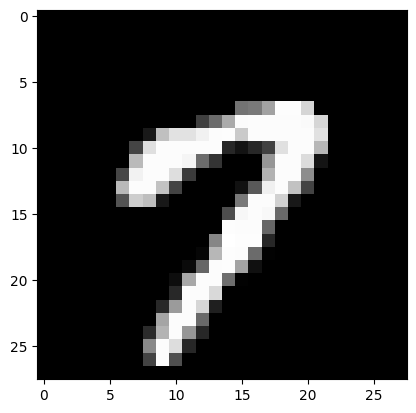

In [4]:
# Testar o dataset
i = 15
plt.imshow(x_train[i], cmap='gray')
print(y_train[i])

In [5]:
# Criar o modelo
model = models.Sequential(
    [
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Compilar o modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# Treinar o modelo
model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9262 - loss: 0.2579
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9665 - loss: 0.1122
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0763
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9822 - loss: 0.0580
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9868 - loss: 0.0445
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9891 - loss: 0.0355
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9912 - loss: 0.0278
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9929 - loss: 0.0230
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9944 - loss: 0.0178
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9952 - loss: 0.0157


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


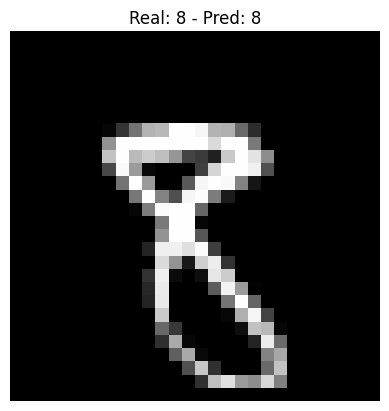

In [8]:
# Testar o modelo com dados que ele não viu
i = 2004 # nº no dataset
img = x_test[i].reshape(1, 28, 28)
pred = model.predict(img).argmax()

plt.imshow(x_test[i], cmap='gray')
plt.title(f'Real: {y_test[i]} - Pred: {pred}')
plt.axis("off")
plt.show()

In [9]:
# Teste do conjunto de teste
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Acurácia: \t{acc}\nImprecisão: \t\t{loss}')

Acurácia: 	0.9779000282287598
Imprecisão: 		0.07731036096811295


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


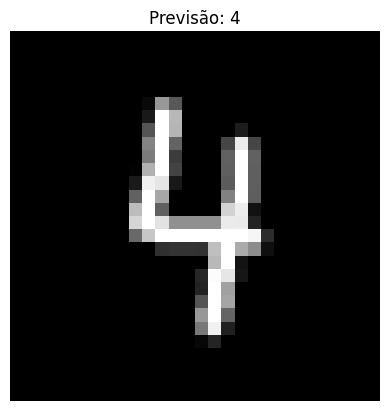

In [10]:
# Carregar a imagem real
img = Image.open("digito.png").convert("L") # Escala de cinza

# Redimensionamento de imagem
img = img.resize((28, 28))

# Converter para array e normalizar
img_array = np.array(img) / 255.0

# Ajuste de shape
img_array = img_array.reshape(1, 28, 28)

# Predição
pred = model.predict(img_array)
digito = pred.argmax()

plt.imshow(img_array[0], cmap='gray')
plt.title(f'Previsão: {digito}')
plt.axis("off")
plt.show()

In [11]:
np.set_printoptions(precision=20, suppress=True)
print(pred)

[[0.00000000000001042746 0.00000018323014       0.00000000000012338013
  0.000000000007380861   0.9999988              0.000000000057427216
  0.000000000004842297   0.00000021785549       0.000000000031172294
  0.00000087369955      ]]
